# Phase 14 — GPQA Diamond: L-SML vs Sampling-Based Baselines (arXiv:2603.19118)

**Goal**: Direct same-model, same-dataset comparison of our spectral L-SML against the
black-box baselines from *How Uncertainty Estimation Scales with Sampling in Reasoning Models*
(Del et al., arXiv:2603.19118, 2026).

| | Our method | Their method |
|---|---|---|
| **Model** | deepseek-ai/DeepSeek-R1-0528-Qwen3-8B | same |
| **Dataset** | GPQA Diamond (198 examples) | same |
| **Metric** | AUROC (correct/incorrect) | same |
| **Compute** | K=1 gray-box (entropy trace) | K=2 black-box (SC+VC) |
| **Access** | Token probabilities (gray-box) | Output text only (black-box) |

Reference numbers from paper Table 5 (DeepSeek-R1-8B row):  
VC@K=2 = 77.0±2.0, SC@K=2 = 64.8±3.0, SCVC@K=2 = 80.3±1.5

**Note on arXiv:2508.20384**: The EAS paper is NOT a hallucination-detection paper —
it explicitly targets uncertainty correlation (Pearson r with answer diversity entropy),
not correctness AUROC. Excluded from this comparison.

In [ ]:
# Cell 1 — Clone + pip install + imports
import os, sys, shutil

os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
os.environ['HF_HOME'] = '/content/drive/MyDrive/hf_cache'

REPO_DIR = '/content/hallucination_detection'

if os.path.exists(REPO_DIR) and not os.path.exists(os.path.join(REPO_DIR, 'spectral_utils')):
    shutil.rmtree(REPO_DIR)

if not os.path.exists(REPO_DIR):
    os.system(f'git clone -b master https://github.com/omrisegev/hallucination_detection.git {REPO_DIR}')
else:
    os.system(f'git -C {REPO_DIR} pull -q')

if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

os.system('pip install -q "transformers>=4.40" accelerate datasets bitsandbytes autoawq scipy scikit-learn')

from spectral_utils import (
    load_model, generate_full, free_memory,
    extract_all_features, sw_var_peak_adaptive,
    FEAT_NAMES, load_cache, save_cache,
    zscore, boot_auc, sml_unsupervised,
    lsml_continuous_pipeline,
    load_gpqa, gpqa_prompt_and_answer, is_correct_gpqa,
    compute_edis,
    parse_verbalized_confidence, VERBALIZED_CONF_SUFFIX,
)
from spectral_utils.data_loaders import extract_gpqa_answer
import numpy as np, pickle

import datasets  # noqa: F401 — freeze pyarrow in memory before any gptqmodel install
print('spectral_utils imported OK')

In [ ]:
# Cell 2 — Config
MODEL_ID  = 'deepseek-ai/DeepSeek-R1-0528-Qwen3-8B'
TEMP      = 0.6     # matches paper recommendation for this model (Del et al., Table A1)
K         = 2       # generate K=2 responses per problem for SC/SCVC baselines
MAX_NEW   = 4096    # DeepSeek-R1 thinking traces need 2k-6k tokens; 1024 truncates before </think>
CACHE_DIR = '/content/drive/MyDrive/hallucination_detection/cache/phase14_gpqa_comparison'

# Feature subset for L-SML continuous (Step 134 GOOD_5)
GOOD_FEATURES = ['epr', 'low_band_power', 'sw_var_peak', 'cusum_max', 'spectral_entropy']

# Reference numbers: arXiv:2603.19118, Table 5, DeepSeek-R1-8B rows, GPQA Diamond
REF_VC_K2   = 0.770   # Verbalized Confidence @ K=2
REF_SC_K2   = 0.648   # Self-Consistency @ K=2
REF_SCVC_K2 = 0.803   # SC + VC hybrid @ K=2

# Offline consensus feature signs — higher value = more likely correct.
# Derived from Step 110 reasoning-domain consensus (MATH/GSM8K cells).
FEATURE_SIGNS = {
    'epr': -1, 'trace_length': 1, 'spectral_entropy': -1,
    'low_band_power': -1, 'high_band_power': -1, 'hl_ratio': -1,
    'dominant_freq': -1, 'spectral_centroid': -1,
    'stft_max_high_power': -1, 'stft_spectral_entropy': -1,
    'rpdi': -1, 'sw_var_peak': -1,
    'pe_mean': -1, 'hurst_exponent': 1,
    'cusum_max': -1, 'cusum_shift_idx': 1,
}

# K=2 rationale: L-SML uses only trace[0] (single forward pass — K=1 effective compute).
# The second response is generated solely to compute SC/SCVC, matching the paper's
# minimum sampling budget for those methods. Our gray-box method uses half the compute.
print(f'Config: {MODEL_ID}, T={TEMP}, K={K}, MAX_NEW={MAX_NEW}')
print(f'Reference: VC@K=2={REF_VC_K2:.1%}, SC@K=2={REF_SC_K2:.1%}, SCVC@K=2={REF_SCVC_K2:.1%}')

In [3]:
# Cell 3 — Mount Google Drive + create cache dirs
from google.colab import drive
drive.mount('/content/drive')

os.makedirs(CACHE_DIR, exist_ok=True)
print(f'Cache dir ready: {CACHE_DIR}')

Mounted at /content/drive
Cache dir ready: /content/drive/MyDrive/hallucination_detection/cache/phase14_gpqa_comparison


In [4]:
# Cell 4 — Load GPQA Diamond (198 examples)
rows = load_gpqa()
prompts_list, correct_letters = zip(*[gpqa_prompt_and_answer(r, i) for i, r in enumerate(rows)])
prompts_list  = list(prompts_list)
correct_letters = list(correct_letters)
print(f'Loaded {len(rows)} GPQA Diamond examples')

Loaded 198 GPQA Diamond problems.
Loaded 198 GPQA Diamond examples


In [5]:
# Cell 5 — Load model
# DeepSeek-R1-0528-Qwen3-8B: 8B dense, bfloat16 ~16 GB — safe on A100 without quantization.
mdl, tok = load_model(MODEL_ID, quantize_4bit=False)
print(f'Model loaded: {MODEL_ID}')

[transformers] Unrecognized keys in `rope_parameters` for 'rope_type'='yarn': {'attn_factor'}
[transformers] Unrecognized keys in `rope_parameters` for 'rope_type'='yarn': {'attn_factor'}


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/399 [00:00<?, ?it/s]

Loaded deepseek-ai/DeepSeek-R1-0528-Qwen3-8B
Model loaded: deepseek-ai/DeepSeek-R1-0528-Qwen3-8B


In [ ]:
# Cell 6 — Inference loop (K=2 responses + VC pass per problem)
# Three-branch reload: memory -> pkl -> compute. Saves every 25 problems.
# FORCE_RECOMPUTE=True because prior cache used MAX_NEW=1024 — all responses truncated
# before </think>, so labels and SC scores are invalid. Must rerun with MAX_NEW=4096.

import time
RAW_PATH = f'{CACHE_DIR}/deepseek_r1_8b_gpqa_k2.pkl'
FORCE_RECOMPUTE = True  # prior cache truncated (no </think> in any of 198 responses)

if not FORCE_RECOMPUTE and 'raw_results' in globals() and raw_results:
    print(f'already in memory ({len(raw_results)} rows); skipping')
elif not FORCE_RECOMPUTE and os.path.exists(RAW_PATH):
    with open(RAW_PATH, 'rb') as f:
        raw_results = pickle.load(f)
    # Validate: check that at least some responses completed thinking
    n_complete = sum(1 for r in raw_results if '</think>' in r['texts'][0])
    if n_complete == 0:
        print(f'WARNING: 0/{len(raw_results)} responses have </think> — cache truncated. Recomputing.')
        raw_results = []
    else:
        acc_check = sum(r['corrects'][0] for r in raw_results) / len(raw_results)
        print(f'loaded from {RAW_PATH} ({len(raw_results)} rows, {n_complete} complete, acc={acc_check:.1%})')
else:
    raw_results = []

resume_idx = len(raw_results)
if resume_idx < len(rows):
    print(f'Running from idx {resume_idx} / {len(rows)}...')
    t0 = time.time()
    for i in range(resume_idx, len(rows)):
        prompt = prompts_list[i]
        correct = correct_letters[i]

        # K=2 main responses (entropy traces + SC)
        texts, traces, answers = [], [], []
        for _ in range(K):
            _r = generate_full(
                mdl, tok, prompt,
                temperature=TEMP, K=15, max_new_tokens=MAX_NEW
            )
            texts.append(_r['full_text'])
            traces.append(_r['token_entropies'])
            answers.append(is_correct_gpqa(_r['full_text'], correct))

        # VC pass: prompt + model's own response + confidence suffix, T=0
        vc_prompt = prompt + '\n\n' + texts[0] + VERBALIZED_CONF_SUFFIX
        _vc_r = generate_full(
            mdl, tok, vc_prompt,
            temperature=0.0, K=1, max_new_tokens=20
        )
        vc_conf = parse_verbalized_confidence(_vc_r['full_text'])

        raw_results.append({
            'idx':     i,
            'texts':   texts,
            'traces':  traces,
            'corrects': answers,    # list of K booleans
            'vc_conf': vc_conf,     # float in [0,1] or NaN
        })

        if (i + 1) % 25 == 0 or i + 1 == len(rows):
            with open(RAW_PATH, 'wb') as f:
                pickle.dump(raw_results, f)
            print(f'  {i+1}/{len(rows)}  elapsed={time.time()-t0:.0f}s')

    with open(RAW_PATH, 'wb') as f:
        pickle.dump(raw_results, f)
    acc = np.mean([r['corrects'][0] for r in raw_results])
    print(f'Done. Accuracy (response 0): {acc:.1%}')
    print(f'Saved to {RAW_PATH}')
else:
    print(f'All {len(rows)} rows complete; skipping inference')

Problems completed : 198 / 198
Problems remaining : 0

Responses per problem: min=2, max=2, all=True
No index gaps — sequential from 0 to 197


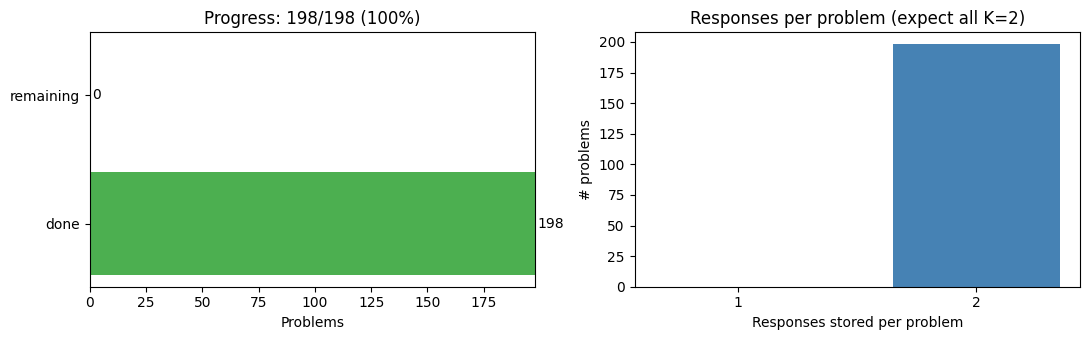

In [7]:

# Cell 6b — Cache coverage diagnostic
import matplotlib.pyplot as plt

# Load from pkl if not already in memory
if 'raw_results' not in globals() or not raw_results:
    if os.path.exists(RAW_PATH):
        with open(RAW_PATH, 'rb') as f:
            raw_results = pickle.load(f)
        print(f'Loaded from {RAW_PATH}')
    else:
        print('No cache found yet.')
        raw_results = []

n_total   = len(rows)          # 198 GPQA problems
n_done    = len(raw_results)
n_pending = n_total - n_done

print(f'Problems completed : {n_done} / {n_total}')
print(f'Problems remaining : {n_pending}')

if n_done == 0:
    print('Nothing saved yet.')
else:
    # Responses per problem (should all be K=2)
    resp_counts = [len(r['corrects']) for r in raw_results]
    indices     = [r['idx'] for r in raw_results]
    expected_indices = list(range(n_done))
    gaps = sorted(set(expected_indices) - set(indices))

    print(f'\nResponses per problem: min={min(resp_counts)}, max={max(resp_counts)}, '
          f'all={len(set(resp_counts))==1}')
    if gaps:
        print(f'WARNING: missing indices: {gaps}')
    else:
        print(f'No index gaps — sequential from 0 to {n_done - 1}')

    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

    # Left: progress bar
    ax = axes[0]
    ax.barh(['done', 'remaining'], [n_done, n_pending], color=['#4CAF50', '#ddd'])
    ax.set_xlim(0, n_total)
    ax.set_xlabel('Problems')
    ax.set_title(f'Progress: {n_done}/{n_total} ({n_done/n_total:.0%})')
    for v, label in zip([n_done, n_pending], [n_done, n_pending]):
        ax.text(v + 1, 0 if label == n_done else 1, str(v), va='center')

    # Right: histogram of responses per problem
    ax = axes[1]
    ax.hist(resp_counts, bins=range(1, max(resp_counts) + 2), align='left',
            color='steelblue', rwidth=0.7)
    ax.set_xlabel('Responses stored per problem')
    ax.set_ylabel('# problems')
    ax.set_title('Responses per problem (expect all K=2)')
    ax.set_xticks(range(1, max(resp_counts) + 1))

    plt.tight_layout()
    plt.show()

In [8]:
# Cell 7 — Spectral feature extraction (trace[0] only) + unload model
FEATS_PATH = f'{CACHE_DIR}/deepseek_r1_8b_gpqa_feats.pkl'
FORCE_RECOMPUTE_FEATS = False

if not FORCE_RECOMPUTE_FEATS and 'features' in globals() and features:
    print(f'features in memory ({len(features)} rows); skipping')
elif not FORCE_RECOMPUTE_FEATS and os.path.exists(FEATS_PATH):
    with open(FEATS_PATH, 'rb') as f:
        features = pickle.load(f)
    print(f'loaded features from {FEATS_PATH}')
else:
    features = []
    for r in raw_results:
        trace = r['traces'][0]
        feats = extract_all_features(trace)
        if feats is not None and trace and len(trace) > 0:
            feats['sw_var_peak'] = sw_var_peak_adaptive(trace)
        features.append(feats)
    with open(FEATS_PATH, 'wb') as f:
        pickle.dump(features, f)
    print(f'Feature extraction done. Saved to {FEATS_PATH}')

del mdl, tok
free_memory()
print('Model unloaded')

loaded features from /content/drive/MyDrive/hallucination_detection/cache/phase14_gpqa_comparison/deepseek_r1_8b_gpqa_feats.pkl
Model unloaded


In [9]:
# Cell 8 — Compute baseline scores (SC, SCVC, mean entropy, EDIS)
from sklearn.metrics import roc_auc_score

labels = np.array([int(r['corrects'][0]) for r in raw_results])
print(f'N={len(labels)}, accuracy (response 0)={labels.mean():.1%}')


def safe_auc(lbl, scores):
    mask = ~np.isnan(scores)
    if mask.sum() < 10 or lbl[mask].sum() == 0 or lbl[mask].sum() == mask.sum():
        return np.nan
    return roc_auc_score(lbl[mask], scores[mask])


# Self-Consistency (K=2): 1.0 if both responses give same answer letter, else 0.5
sc_scores = np.array([
    1.0 if extract_gpqa_answer(r['texts'][0]) == extract_gpqa_answer(r['texts'][1]) else 0.5
    for r in raw_results
])

# Verbalized Confidence (from VC pass)
vc_scores = np.array([r['vc_conf'] for r in raw_results])

# SCVC hybrid (lambda=0.5, matching paper)
vc_safe = np.where(np.isnan(vc_scores), 0.5, vc_scores)
scvc_scores = 0.5 * sc_scores + 0.5 * vc_safe

# Mean entropy: negated so higher = more confident = more likely correct
mean_ent_scores = np.array([
    -np.mean(r['traces'][0]) if r['traces'][0] and len(r['traces'][0]) > 0 else np.nan
    for r in raw_results
])

# EDIS: negated (lower instability = more likely correct)
edis_scores = np.array([
    -compute_edis(r['traces'][0]) if r['traces'][0] and len(r['traces'][0]) > 0 else np.nan
    for r in raw_results
])

print(f'VC coverage:   {(~np.isnan(vc_scores)).sum()}/{len(vc_scores)}')
print(f'EDIS coverage: {(~np.isnan(edis_scores)).sum()}/{len(edis_scores)}')
print()
print('Quick AUROCs (no bootstrap):')
print(f'  SC@K=2:       {safe_auc(labels, sc_scores):.3f}  (ref paper: {REF_SC_K2:.3f})')
print(f'  VC@K=1:       {safe_auc(labels, vc_scores):.3f}  (ref paper K=2: {REF_VC_K2:.3f})')
print(f'  SCVC@K=2:     {safe_auc(labels, scvc_scores):.3f}  (ref paper: {REF_SCVC_K2:.3f})')
print(f'  Mean entropy: {safe_auc(labels, mean_ent_scores):.3f}')
print(f'  EDIS (ours):  {safe_auc(labels, edis_scores):.3f}')

N=198, accuracy (response 0)=19.2%
VC coverage:   13/198
EDIS coverage: 198/198

Quick AUROCs (no bootstrap):
  SC@K=2:       0.476  (ref paper: 0.648)
  VC@K=1:       0.833  (ref paper K=2: 0.770)
  SCVC@K=2:     0.467  (ref paper: 0.803)
  Mean entropy: 0.401
  EDIS (ours):  0.389


In [ ]:
# Cell 9 — L-SML continuous AUROC (bootstrapped) + individual feature table
# Uses lsml_continuous_pipeline (Step 134 GOOD_5, no binarization).

valid_mask = np.array([f is not None for f in features])
fd_raw = {
    fn: np.array([
        features[i].get(fn, np.nan) if features[i] is not None else np.nan
        for i in range(len(features))
    ])
    for fn in FEAT_NAMES
}
fd_valid = {fn: fd_raw[fn][valid_mask] for fn in FEAT_NAMES}

lsml_full = np.full(len(labels), np.nan)
try:
    fused_scores, meta = lsml_continuous_pipeline(fd_valid, GOOD_FEATURES, FEATURE_SIGNS)
    lsml_full[valid_mask] = fused_scores
except Exception as e:
    print(f'L-SML continuous error: {e}')
    meta = None

# Bootstrap AUROC — take max(positive, negative) for sign safety
p_auc, p_lo, p_hi = boot_auc(labels[valid_mask], lsml_full[valid_mask])
n_auc, n_lo, n_hi = boot_auc(labels[valid_mask], -lsml_full[valid_mask])
if p_auc >= n_auc:
    lsml_auc, lsml_lo, lsml_hi = p_auc, p_lo, p_hi
else:
    lsml_auc, lsml_lo, lsml_hi = n_auc, n_lo, n_hi

print(f'L-SML continuous AUROC: {lsml_auc:.3f}  [{lsml_lo:.3f}, {lsml_hi:.3f}]')
if meta is not None:
    print(f'  K={meta["K"]}, method={meta["method"]}, residual={meta["residual"]:.4f}')
print()

# Individual feature AUROCs (oriented by FEATURE_SIGNS)
feat_aucs = {}
print(f'{"Feature":<24} {"AUROC":>8}')
print('-' * 35)
for fn in FEAT_NAMES:
    sign = FEATURE_SIGNS.get(fn, 1)
    auc = safe_auc(labels, fd_raw[fn] * sign)
    feat_aucs[fn] = auc
    bar = '▓' * int(max(0, auc - 0.5) * 40) if not np.isnan(auc) else ''
    print(f'{fn:<24} {auc:.3f}  {bar}')

In [ ]:
# Cell 10 — Final comparison table: L-SML vs arXiv:2603.19118

sc_auc   = safe_auc(labels, sc_scores)
vc_auc   = safe_auc(labels, vc_scores)
scvc_auc = safe_auc(labels, scvc_scores)
me_auc   = safe_auc(labels, mean_ent_scores)
edis_auc = safe_auc(labels, edis_scores)

W = 72
print('=' * W)
print('GPQA Diamond — L-SML vs Sampling-Based Baselines (arXiv:2603.19118)')
print(f'Model: {MODEL_ID}  |  N=198  |  T={TEMP}')
print('=' * W)
print(f'{"Method":<32} {"K":<4} {"Type":<12} {"AUROC":>7}  {"Ref":>8}')
print('-' * W)
print(f'{"L-SML (ours)":<32} {"K=1":<4} {"gray-box":<12} {lsml_auc:>7.3f}  {"—":>8}')
print(f'{"EDIS (ours)":<32} {"K=1":<4} {"gray-box":<12} {edis_auc:>7.3f}  {"—":>8}')
print(f'{"Mean entropy":<32} {"K=1":<4} {"gray-box":<12} {me_auc:>7.3f}  {"—":>8}')
print(f'{"VC (reproduced)":<32} {"K=1":<4} {"black-box":<12} {vc_auc:>7.3f}  {REF_VC_K2:>8.3f}')
print(f'{"SC (reproduced)":<32} {"K=2":<4} {"black-box":<12} {sc_auc:>7.3f}  {REF_SC_K2:>8.3f}')
print(f'{"SCVC (reproduced)":<32} {"K=2":<4} {"black-box":<12} {scvc_auc:>7.3f}  {REF_SCVC_K2:>8.3f}')
print('-' * W)
print(f'{"[ref] VC@K=2  (2603.19118)":<32} {"K=2":<4} {"black-box":<12} {REF_VC_K2:>7.3f}  {"Table 5":>8}')
print(f'{"[ref] SCVC@K=2 (2603.19118)":<32} {"K=2":<4} {"black-box":<12} {REF_SCVC_K2:>7.3f}  {"Table 5":>8}')
print('=' * W)
print()
print(f'L-SML@K=1 vs SCVC@K=2 paper: {lsml_auc:.3f} vs {REF_SCVC_K2:.3f}  ({lsml_auc - REF_SCVC_K2:+.3f})')
print(f'L-SML@K=1 vs VC@K=1 reproduced: {lsml_auc:.3f} vs {vc_auc:.3f}  ({lsml_auc - vc_auc:+.3f})')
print()
print('Key: our gray-box K=1 method vs their black-box K=2 — half the forward passes.')
print('VC@K=1 reproduced here is the 1-pass black-box reference on the same model.')

In [ ]:
# Cell 11 — Save results
RESULTS_PATH = f'{CACHE_DIR}/phase14_results.pkl'
FORCE_SAVE = True

if not FORCE_SAVE and os.path.exists(RESULTS_PATH):
    print(f'Results already at {RESULTS_PATH}; skipping')
else:
    results = {
        'model':         MODEL_ID,
        'n_samples':     len(labels),
        'labels':        labels,
        'lsml_auc':      lsml_auc,
        'lsml_lo':       lsml_lo,
        'lsml_hi':       lsml_hi,
        'sc_auc':        sc_auc,
        'vc_auc':        vc_auc,
        'scvc_auc':      scvc_auc,
        'edis_auc':      edis_auc,
        'mean_ent_auc':  me_auc,
        'ref_vc_k2':     REF_VC_K2,
        'ref_sc_k2':     REF_SC_K2,
        'ref_scvc_k2':   REF_SCVC_K2,
        'feat_aucs':     feat_aucs,
        'lsml_scores':   lsml_full,
        'sc_scores':     sc_scores,
        'vc_scores':     vc_scores,
        'edis_scores':   edis_scores,
    }
    with open(RESULTS_PATH, 'wb') as f:
        pickle.dump(results, f)
    print(f'Saved to {RESULTS_PATH}')